# Modele 2 - Prediction de la duree de visite

Reentrainement du modele de regression pour supporter **10 categories** au lieu de 7 :
ajout de `restaurant`, `cafe` et `hotel` aux 7 categories d'origine.

**Entrees** : `categorie`, `note` (0-5), `longueur_description` (nombre de caracteres)
**Sortie** : duree de visite estimee, en minutes

**Architecture** (reprise du modele original) :
`ColumnTransformer(OneHotEncoder(categorie) + StandardScaler(note, longueur_description))`
-> `LinearRegression`

**A propos des donnees d'entrainement** : il n'existe pas de jeu de donnees reel mesurant le
temps que les touristes passent sur chaque lieu d'Azemmour. Le modele original comme celui-ci
s'appuient donc sur une **duree de base par categorie, documentee ci-dessous**, a laquelle on
ajoute un effet de la note et de la longueur de description, plus du bruit aleatoire pour
simuler la variabilite naturelle. Cette methode est transparente et remplacable : si des
donnees reelles de duree de visite deviennent disponibles un jour, il suffit de remplacer la
fonction `make_synthetic_rows` par un chargement de ces donnees.

In [1]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = os.path.join("..", "data", "places_store.json")
MODEL_OUT_PATH = os.path.join("..", "models", "model_regression_duree.joblib")

## 1. Lieux reels (pour verifier la couverture des categories)

In [2]:
with open(DATA_PATH, encoding="utf-8") as f:
    places = json.load(f)

real_df = pd.DataFrame(places)
print(f"{len(real_df)} lieux reels")
real_df["categorie"].value_counts().sort_index()

15 lieux reels


categorie
art             2
artisanat       1
evenementiel    1
hotel           2
monument        3
nature          1
plage           1
religieux       3
restaurant      1
Name: count, dtype: int64

## 2. Duree de base par categorie (heuristique documentee)

| Categorie | Duree de base | Justification |
|---|---|---|
| plage | 110 min | activite longue (baignade, detente, sports nautiques) |
| evenementiel | 80 min | expositions/concerts, visite prolongee |
| restaurant | 65 min | temps d'un repas |
| nature | 55 min | promenade |
| monument | 45 min | visite guidee moyenne |
| artisanat | 35 min | atelier/boutique |
| religieux | 30 min | recueillement bref |
| art | 30 min | galerie, parcours court |
| cafe | 25 min | pause rapide |
| hotel | 20 min | halte / check-in, pas la duree du sejour complet |

In [3]:
BASE_DURATION = {
    "plage": 110,
    "evenementiel": 80,
    "restaurant": 65,
    "nature": 55,
    "monument": 45,
    "artisanat": 35,
    "religieux": 30,
    "art": 30,
    "cafe": 25,
    "hotel": 20,
}
# Toutes les categories presentes dans les donnees reelles doivent avoir une duree de
# base (l'inverse n'est pas requis : une categorie peut ne temporairement avoir aucun
# lieu reel dans places_store.json sans que ca invalide sa duree de base).
manquantes = set(real_df["categorie"].unique()) - set(BASE_DURATION)
assert not manquantes, f"categorie(s) sans duree de base : {manquantes}"
print(f"{len(BASE_DURATION)} categories couvertes par BASE_DURATION,",
      f"{real_df['categorie'].nunique()} presentes dans les donnees reelles actuelles.")

10 categories couvertes par BASE_DURATION, 9 presentes dans les donnees reelles actuelles.


## 3. Generation du jeu d'entrainement synthetique

Pour chaque categorie, on tire aleatoirement des notes et longueurs de description
plausibles, on applique la duree de base + un effet note + un effet longueur + du bruit.

In [4]:
rng = np.random.default_rng(42)


def make_synthetic_rows(n_per_category=30):
    rows = []
    for cat, base in BASE_DURATION.items():
        notes = rng.uniform(3.0, 5.0, n_per_category)
        desc_lens = rng.integers(30, 220, n_per_category)
        for note, desc_len in zip(notes, desc_lens):
            note_effect = (note - 4.0) * 6       # une meilleure note allonge legerement la visite
            len_effect = (desc_len - 100) * 0.05  # une description plus riche => lieu plus interessant
            noise = rng.normal(0, 6)
            duree = max(10, base + note_effect + len_effect + noise)
            rows.append({
                "categorie": cat,
                "note": round(float(note), 1),
                "longueur_description": int(desc_len),
                "duree_visite_min": round(float(duree), 1),
            })
    return pd.DataFrame(rows)


synthetic_df = make_synthetic_rows()
print(f"{len(synthetic_df)} exemples synthetiques ({len(BASE_DURATION)} categories x 30)")
synthetic_df.groupby("categorie")["duree_visite_min"].agg(["mean", "std"]).round(1)

300 exemples synthetiques (10 categories x 30)


,mean,std
categorie,,
art,30.6,6.7
artisanat,35.6,7.6
cafe,27.2,8.1
evenementiel,80.8,7.4
hotel,20.5,7.4
monument,47.3,7.1
nature,56.1,7.8
plage,111.9,7.4
religieux,30.0,7.6


## 4. Entrainement et evaluation

In [5]:
X = synthetic_df[["categorie", "note", "longueur_description"]]
y = synthetic_df["duree_visite_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


def build_pipeline():
    return Pipeline([
        ("prep", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["categorie"]),
            ("num", StandardScaler(), ["note", "longueur_description"]),
        ])),
        ("reg", LinearRegression()),
    ])


pipeline = build_pipeline()
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, y_pred):.1f} min")
print(f"R2  : {r2_score(y_test, y_pred):.3f}")

MAE : 4.2 min
R2  : 0.962


## 5. Predictions vs realite (holdout)

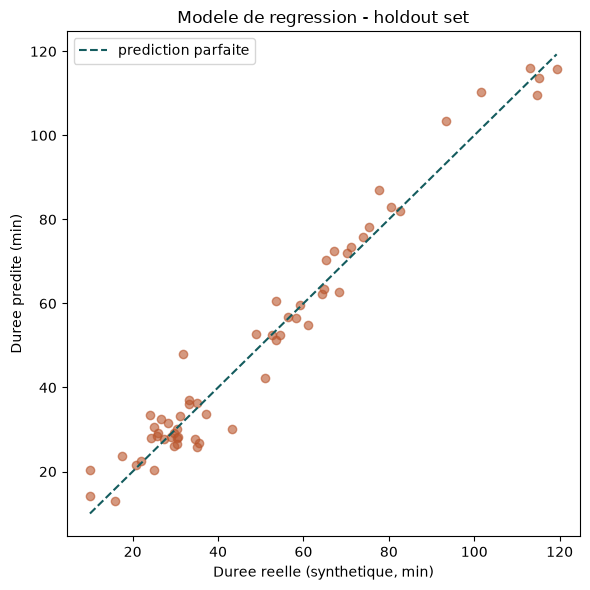

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="#b9552c")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "--", color="#145c5e", label="prediction parfaite")
plt.xlabel("Duree reelle (synthetique, min)")
plt.ylabel("Duree predite (min)")
plt.title("Modele de regression - holdout set")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Reentrainement final sur toutes les donnees synthetiques

In [7]:
final_pipeline = build_pipeline()
final_pipeline.fit(X, y)
print("Modele final entraine sur", len(X), "exemples,", len(BASE_DURATION), "categories.")

Modele final entraine sur 300 exemples, 10 categories.


## 7. Test de fumee : une prediction par categorie (note=4.0, description moyenne)

In [8]:
for cat in BASE_DURATION:
    sample = pd.DataFrame([{"categorie": cat, "note": 4.0, "longueur_description": 100}])
    pred = final_pipeline.predict(sample)[0]
    print(f"{cat:15s} -> {pred:5.0f} min")

plage           ->   110 min
evenementiel    ->    80 min
restaurant      ->    64 min
nature          ->    56 min
monument        ->    45 min
artisanat       ->    34 min
religieux       ->    29 min
art             ->    29 min
cafe            ->    25 min
hotel           ->    19 min


## 8. Sauvegarde du modele

In [9]:
joblib.dump(final_pipeline, MODEL_OUT_PATH)
print("Modele sauvegarde :", os.path.abspath(MODEL_OUT_PATH))

Modele sauvegarde : C:\Users\XPRISTO\PycharmProjects\webapp\backend\models\model_regression_duree.joblib


## Limites et pistes d'amelioration

- Les durees d'entrainement sont **synthetiques** (base par categorie + bruit), pas mesurees
  sur de vrais visiteurs. Le modele apprend donc a reproduire une heuristique raisonnable,
  pas un comportement touristique reel.
- Le `OneHotEncoder` utilise `handle_unknown="ignore"` : si une future categorie apparait sans
  reentrainement, le modele ne plante pas mais ignore simplement le signal de categorie pour
  cette prediction (comportement verifie sur le modele precedent avec `hotel`/`cafe`/`restaurant`
  avant leur ajout ici).
- Piste d'amelioration : remplacer `make_synthetic_rows` par de vraies donnees si un jour
  l'app collecte le temps de visite reel des utilisateurs.